# Weather Data as External Features for SE3 Electricity Demand Forecasting

## Research Problem

Weather is an important external driver of electricity demand. Variables such as
temperature, humidity, wind speed, and solar radiation can help explain changes in
electricity consumption, particularly because heating and other weather-sensitive
activities respond strongly to meteorological conditions.

However, an important methodological question arises when weather is used as an
external feature in a **day-ahead electricity demand forecasting model**:

> **Should the model use observed historical weather or weather forecasts?**

This distinction matters because the actual weather at the target time is not known
when a day-ahead demand forecast is produced.

For example, when predicting electricity demand for tomorrow at 15:00, the model
cannot know tomorrow's realized temperature. It only has access to the temperature
forecast available at the forecast issuance time.

Therefore, two different weather datasets can be considered:

1. **Observed / reanalysis weather**
   - Represents an estimate of the weather that actually occurred.
   - Examples include ERA5 and MERRA-2.
   - Using this information for the future forecast period creates an **ex-post**
     or "perfect-weather" forecasting experiment.

2. **Historical Numerical Weather Prediction (NWP) forecasts**
   - Represent weather information that would actually have been available when
     the electricity-demand forecast was issued.
   - This creates an **ex-ante / operational** forecasting experiment.

---

## Literature Review

### Yang, Wang & Hong (2022)

Yang, Wang and Hong (2022) argue that energy forecasting studies are often conducted
under an **ex-post forecasting setting**, where actual weather observations during
the forecast period are used as model inputs.

This can create a gap between academic forecasting experiments and real operational
forecasting, because actual future weather is not available when the forecast is made.

To address this problem, the authors constructed a historical weather forecast dataset
using operational forecasts from the **ECMWF High Resolution (HRES) model**. The
dataset contains four years (2017–2020) of operational weather forecasts and was
specifically designed for applications including electricity load forecasting.

**Reference:**

Yang, D., Wang, W., & Hong, T. (2022). *A historical weather forecast dataset from
the European Centre for Medium-Range Weather Forecasts (ECMWF) for energy forecasting*.
Solar Energy, 232, 263–274.
https://doi.org/10.1016/j.solener.2021.12.011


### De Felice, Alessandri & Ruti (2013)

De Felice et al. (2013) directly investigated the effect of weather information on
electricity-demand forecasting.

Their study used two forms of weather information:

- weather **reanalysis**
- operational **NWP weather forecasts**

The authors used reanalysis to investigate the potential predictability of electricity
demand when high-quality information about the realized weather is available, while
operational forecasts represented the weather information available in a realistic
forecasting environment.

Importantly, they compared electricity-demand forecasting performance under these
two weather-information conditions. The difference between them provides information
about how weather-forecast uncertainty affects electricity-demand forecast accuracy.

**Reference:**

De Felice, M., Alessandri, A., & Ruti, P. M. (2013). *Electricity demand forecasting
over Italy: Potential benefits using numerical weather prediction models*.
Electric Power Systems Research, 104, 71–79.
https://doi.org/10.1016/j.epsr.2013.06.004


### Pinheiro, Madeira & Francisco (2023)

Pinheiro et al. (2023) developed a short-term electricity load forecasting framework
using historical electricity demand, calendar variables, and meteorological information.

For operational forecasting, the study used **Numerical Weather Prediction (NWP)**
data. The NWP forecasts were updated twice per day (00 and 12 UTC) and provided
weather predictions for the following 72 hours.

The study therefore provides an example of how weather forecasts can be incorporated
into an operational short-term electricity load forecasting system.

**Reference:**

Pinheiro, M. G., Madeira, S. C., & Francisco, A. P. (2023). *Short-term electricity
load forecasting—A systematic approach from system level to secondary substations*.
Applied Energy, 332, 120493.
https://doi.org/10.1016/j.apenergy.2022.120493


## Conclusion from the Literature

The literature suggests that observed/reanalysis weather and historical weather
forecasts answer **different forecasting questions**.

Observed or reanalysis weather can be used to investigate:

> How well can electricity demand be predicted if future weather conditions are
> known accurately?

Historical NWP forecasts can instead investigate:

> How well could electricity demand actually have been predicted using weather
> information available at the time?

Based on this distinction, two separate forecasting experiments are designed for
the SE3 electricity-demand forecasting problem.

# Experimental Design: Reanalysis Weather vs Historical Weather Forecasts

Based on the literature review, two experiments are designed to investigate how
weather information should be incorporated into SE3 day-ahead electricity-demand
forecasting.

The objective is not only to determine whether weather improves demand forecasting,
but also to distinguish between:

- the predictive value of weather itself; and
- the performance achievable when weather is uncertain and must also be forecast.

---

## Experiment A — Ex-Post / Reanalysis Weather

This experiment uses historical **observed or reanalysis weather**.

The weather variables represent estimates of the meteorological conditions that
actually occurred at the target time.

This experiment therefore approximates a situation in which the future weather is
known accurately.

Its purpose is to answer:

> **How well could SE3 electricity demand be predicted if future weather conditions
> were known?**



---

## Experiment B — Ex-Ante / Operational Forecasting

This experiment uses **historical NWP weather forecasts**.

Instead of using the weather that eventually occurred, the model receives the weather
forecast that would have been available when the day-ahead electricity-demand forecast
was issued.

Its purpose is to answer:

> **How well could SE3 electricity demand actually have been predicted using the
> weather information available at the forecast issuance time?**



---

## Combined Experimental Structure

                              SE3 LOAD FORECASTING
                                       │
                    ┌──────────────────┴──────────────────┐
                    │                                     │
             EXPERIMENT A                          EXPERIMENT B
              Ex-Post                               Ex-Ante
                    │                                     │
          Reanalysis Weather                    Historical NWP
          "realized weather"                       Forecasts
                    │                                     │
                    ▼                                     ▼
                 XGBoost                               XGBoost
                    │                                     │
                    ▼                                     ▼
              SE3 Demand                            SE3 Demand
                    │                                     │
                    └──────────────────┬──────────────────┘
                                       │
                                       ▼
                              Compare Performance
                             MAE / RMSE / MAPE etc.


## Main Comparison

If both weather datasets are available for the same evaluation period, the models
can be compared directly.

The difference between the two experiments can be interpreted as an indication of
the effect of **weather-forecast uncertainty** on electricity-demand forecasting.

Conceptually:

Weather-related forecasting gap

    = Error using historical NWP forecasts
      − Error using reanalysis weather

Experiment A therefore provides an approximate **perfect-weather benchmark**, while
Experiment B represents the more realistic **operational forecasting scenario**.

For a fair comparison, the two experiments should ideally use the same demand data,
model architecture, calendar features, lag features, training/testing periods, and
evaluation metrics. The main experimental difference should be the source of the
weather information.

# Candidate Weather Data Sources

## Experiment A — Observed / Reanalysis Weather

| Resource                              | Data Type                             | Link                                                                     |
| ------------------------------------- | ------------------------------------- | ------------------------------------------------------------------------ |
| **ECMWF ERA5**                        | Reanalysis                            | https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels |
| **ECMWF ERA5-Land**                   | Land reanalysis                       | https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land          |
| **NASA MERRA-2**                      | Reanalysis                            | https://gmao.gsfc.nasa.gov/reanalysis/MERRA-2/                           |
| **Renewables.ninja**                  | MERRA-2-based historical weather      | https://www.renewables.ninja/                                            |
| **Open-Meteo Historical Weather API** | ERA5 / ERA5-Land / historical weather | https://open-meteo.com/en/docs/historical-weather-api                    |

## Experiment B — Historical Weather Forecasts

| Resource                               | Data Type                                                                           | Link                                                                        |
| -------------------------------------- | ----------------------------------------------------------------------------------- | --------------------------------------------------------------------------- |
| **ECMWF MARS Archive**                 | Archived operational NWP forecasts                                                  | https://www.ecmwf.int/en/forecasts/access-forecasts/access-archive-datasets |
| **Yang et al. ECMWF HRES Dataset**     | Historical operational NWP forecasts (2017–2020)                                    | https://doi.org/10.1016/j.solener.2021.12.011                               |
| **Open-Meteo Historical Forecast API** | Archived NWP forecasts                                                              | https://open-meteo.com/en/docs/historical-forecast-api                      |
| **Open-Meteo Previous Runs API**       | NWP forecasts at fixed 1–7 day lead times                                           | https://open-meteo.com/en/docs/previous-runs-api                            |
| **Open-Meteo Single Runs API**         | Individual historical NWP model runs; ECMWF IFS HRES 9 km available from March 2024 | https://open-meteo.com/en/docs/single-runs-api                              |

## Production — Live Weather Forecasts

| Resource                             | Data Type                               | Link                                                                            |
| ------------------------------------ | --------------------------------------- | ------------------------------------------------------------------------------- |
| **Open-Meteo ECMWF Forecast API**    | Live ECMWF IFS HRES 9 km forecasts      | https://open-meteo.com/en/docs/ecmwf-api                                        |
| **Open-Meteo Weather Forecast API**  | Live multi-model NWP forecasts          | https://open-meteo.com/en/docs                                                  |
| **ECMWF Open Data**                  | Direct live operational ECMWF forecasts | https://www.ecmwf.int/en/forecasts/datasets/open-data                           |
| **SMHI Meteorological Forecast API** | Live Swedish meteorological forecasts   | https://www.smhi.se/data/sok-oppna-data-i-utforskaren/meteorologisk-prognos-api |

### Preferred End-to-End Combination

For a consistent historical-to-production pipeline:

**Experiment A**

`ERA5 / ERA5-Land → XGBoost → SE3 demand`

**Experiment B**

`Historical ECMWF IFS forecasts → XGBoost → SE3 demand`

**Production**

`Latest ECMWF IFS forecast → trained XGBoost → tomorrow's hourly SE3 demand`

Using the same NWP model family for Experiment B and production reduces the mismatch between the weather data used during model development and the weather data received by the deployed forecasting pipeline.


### Experiment A — ERA5-Land Weather Data

For **Experiment A (Ex-post Load Forecasting)**, historical weather data are obtained from the **ERA5-Land hourly time-series dataset** provided by the Copernicus Climate Data Store (CDS). ERA5-Land is a global reanalysis dataset that provides **hourly weather data at approximately 9 km spatial resolution (0.1° × 0.1° grid)** from 1950 to the present.

For this experiment, weather data are extracted for **Stockholm (59.329° N, 18.068° E)** as a representative weather location for the SE3 bidding zone. The selected variables include temperature, dew-point temperature, wind components, precipitation, and solar radiation.

**Data source:**  
https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=download

In [1]:
%pip install "cdsapi>=0.7.7"

     ---------------------------------------- 0.0/46.7 kB ? eta -:--:--
     ---------------------------------------- 46.7/46.7 kB 2.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/73.1 kB ? eta -:--:--
   ---------------------------------------- 73.1/73.1 kB 3.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/137.0 kB ? eta -:--:--
   ---------------------------------------- 137.0/137.0 kB 4.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/200.6 kB ? eta -:--:--
   ---------------------------------------- 200.6/200.6 kB 6.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/69.6 kB ? eta -:--:--
   ---------------------------------------- 69.6/69.6 kB ? eta 0:00:00
   ---------------------------------------- 0.0/135.7 kB ? eta -:--:--
   ---------------------------------------- 135.7/135.7 kB 7.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/508.3 kB ? eta -:--:--
   --------------------------------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import cdsapi
from pathlib import Path

# Output folder
output_dir = Path("data/weather/ECMWF")
output_dir.mkdir(parents=True, exist_ok=True)

# Output file
output_file = output_dir / "era5_land_stockholm_2018_2026.zip"

# ERA5-Land dataset
dataset = "reanalysis-era5-land-timeseries"

# Request configuration
request = {
    "variable": [
        "2m_dewpoint_temperature",
        "2m_temperature",
        "surface_pressure",
        "total_precipitation",
        "surface_solar_radiation_downwards",
        "surface_thermal_radiation_downwards",
        "skin_temperature",
        "snow_cover",
        "snow_depth",
        "soil_temperature_level_1",
        "soil_temperature_level_2",
        "soil_temperature_level_3",
        "soil_temperature_level_4",
        "volumetric_soil_water_level_1",
        "volumetric_soil_water_level_2",
        "volumetric_soil_water_level_3",
        "volumetric_soil_water_level_4",
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
    ],
    "location": {
        "longitude": 18.068,
        "latitude": 59.329,
    },
    "date": ["2018-01-01/2026-09-01"],
    "data_format": "csv",
}

# Connect to the Copernicus Climate Data Store
client = cdsapi.Client()

# Download the data
client.retrieve(
    dataset,
    request,
    str(output_file),
)

print(f"Downloaded to: {output_file}")

2026-09-21 15:05:14,332 INFO Request ID is 6316673f-f256-4414-93e3-176d798df992
2026-09-21 15:05:16,445 INFO status has been updated to accepted
2026-09-21 15:05:37,748 INFO status has been updated to running
2026-09-21 15:06:06,396 INFO status has been updated to successful
                                                                                          

Downloaded to: data\weather\ECMWF\era5_land_stockholm_2018_2026.csv


## Weather variables and units

All values and column names are kept in their original ERA5-Land units. No unit conversions are applied.

| Column | Meaning | Original unit |
|---|---|---|
| `t2m` | Air temperature at 2 m | Kelvin (K) |
| `d2m` | Dewpoint temperature at 2 m | K |
| `skt` | Surface skin temperature | K |
| `stl1`?`stl4` | Soil temperature, layers 1?4 | K |
| `u10`, `v10` | Eastward/northward wind components at 10 m | m/s |
| `sp` | Surface pressure | Pa |
| `tp` | Accumulated precipitation | m of water |
| `snowc` | Snow cover | % |
| `sde` | Snow depth | m |
| `swvl1`?`swvl4` | Volumetric soil water, layers 1?4 | m?/m? |
| `ssrd` | Downward solar radiation energy | J/m? |
| `strd` | Downward thermal radiation energy | J/m? |
| `latitude`, `longitude` | Grid coordinates | Degrees |

Precipitation and radiation are accumulated quantities. Verify the product's accumulation convention before interpreting them as hourly totals; hourly timestamps alone do not establish the accumulation interval.

Sources: [ERA5-Land time-series catalogue](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview) and [ECMWF ERA5-Land documentation](https://confluence.ecmwf.int/pages/viewpage.action?pageId=143043366).


In [12]:

from pathlib import Path
from zipfile import ZipFile
from functools import reduce

import pandas as pd
from IPython.display import display

# 1. Paths
output_dir = Path("data/weather/ECMWF")
zip_file = output_dir / "era5_land_stockholm_2018_2026.zip"
merged_file = output_dir / "era5_land_stockholm_2018_2026_merged.csv"

if not zip_file.is_file():
    raise FileNotFoundError(
        f"File not found: {zip_file.resolve()}\n"
        f"Available files: {[p.name for p in output_dir.glob('*')]}"
    )

# 2. Read the CSV files inside the ZIP
merge_keys = ["valid_time", "latitude", "longitude"]
frames = []

with ZipFile(zip_file) as archive:
    csv_files = sorted(
        name for name in archive.namelist()
        if name.lower().endswith(".csv")
    )

    if not csv_files:
        raise ValueError("No CSV files found inside the ZIP.")

    for name in csv_files:
        with archive.open(name) as file:
            frame = pd.read_csv(file, parse_dates=["valid_time"])

        print(f"{name}: {frame.shape}")
        frames.append(frame)

# 3. Merge weather variables by timestamp and location
df_weather = reduce(
    lambda left, right: left.merge(
        right,
        on=merge_keys,
        how="outer",
        validate="one_to_one",
    ),
    frames,
)

df_weather = df_weather.set_index("valid_time").sort_index()

# 4. Basic overview
print("\nShape:", df_weather.shape)
print("Time range:", df_weather.index.min(), "to", df_weather.index.max())
print("Columns:", df_weather.columns.tolist())

print("\nFirst rows:")
display(df_weather.head())

print("\nLast rows:")
display(df_weather.tail())

df_weather.info()

# 5. Missing values and column types
overview = pd.DataFrame({
    "Data type": df_weather.dtypes,
    "Nonmissing": df_weather.notna().sum(),
    "Missing": df_weather.isna().sum(),
    "Missing (%)": df_weather.isna().mean().mul(100).round(2),
    "Unique values": df_weather.nunique(),
})

display(overview)

# 6. Summary statistics — values remain in their source units
display(df_weather.describe().T)

# 7. Locations and duplicate records
print("\nLocations:")
display(df_weather[["latitude", "longitude"]].drop_duplicates())

records = df_weather.reset_index()
print(
    "Duplicate timestamp/location records:",
    records.duplicated(subset=merge_keys).sum(),
)

# 8. Timestamp intervals and coverage
timestamps = df_weather.index.dropna().unique().sort_values()

display(
    timestamps.to_series()
    .diff()
    .value_counts()
    .rename_axis("Time interval")
    .to_frame("Count")
)

display(
    pd.Series(timestamps.year)
    .value_counts()
    .sort_index()
    .rename_axis("Year")
    .to_frame("Unique timestamps")
)

if len(timestamps):
    expected_hours = pd.date_range(
        start=timestamps.min(),
        end=timestamps.max(),
        freq="h",
    )
    missing_hours = expected_hours.difference(timestamps)

    print("Missing hourly timestamps across all locations:", len(missing_hours))
    print("First missing timestamps:", missing_hours[:10].tolist())

# 9. Save the merged data as an actual CSV
df_weather.to_csv(merged_file)
print("\nSaved:", merged_file.resolve())

reanalysis-era5-land-timeseries-sfc-2m-temperaturean5fed99.csv: (75984, 5)
reanalysis-era5-land-timeseries-sfc-pressure-precipitationm9s27f1j.csv: (75984, 5)
reanalysis-era5-land-timeseries-sfc-radiation-heatn62udd8k.csv: (75984, 5)
reanalysis-era5-land-timeseries-sfc-skin-temperature6hzlm1uz.csv: (75984, 4)
reanalysis-era5-land-timeseries-sfc-snowf_xako0f.csv: (75984, 5)
reanalysis-era5-land-timeseries-sfc-soil-temperaturesofmkrfu.csv: (75984, 7)
reanalysis-era5-land-timeseries-sfc-soil-water3vl8z00f.csv: (75984, 7)
reanalysis-era5-land-timeseries-sfc-windilunj795.csv: (75984, 5)

Shape: (75984, 21)
Time range: 2018-01-01 00:00:00 to 2026-09-01 23:00:00
Columns: ['d2m', 't2m', 'latitude', 'longitude', 'sp', 'tp', 'ssrd', 'strd', 'skt', 'snowc', 'sde', 'stl1', 'stl2', 'stl3', 'stl4', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'u10', 'v10']

First rows:


,d2m,t2m,latitude,longitude,sp,tp,ssrd,strd,skt,snowc,...,stl1,stl2,stl3,stl4,swvl1,swvl2,swvl3,swvl4,u10,v10
valid_time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,274.55210,274.60410,59.3,18.1,98839.970,0.000831,0.0,1117816.0,274.59183,2.685547,...,275.19885,275.66718,276.66235,279.95230,0.437057,0.428635,0.427429,0.397156,-1.527222,4.483948
2018-01-01 01:00:00,274.80950,274.87103,59.3,18.1,98771.016,0.000382,0.0,1141575.8,274.84357,4.501953,...,275.26820,275.66210,276.66278,279.94977,0.438995,0.429108,0.427414,0.397186,-1.044571,4.526154
2018-01-01 02:00:00,274.99918,275.49158,59.3,18.1,98715.220,0.000123,0.0,1152540.2,275.19415,4.488281,...,275.38885,275.66090,276.66320,279.94727,0.438034,0.429581,0.427414,0.397217,-0.192734,4.067978
2018-01-01 03:00:00,275.46826,275.94240,59.3,18.1,98677.484,0.000017,0.0,1158140.5,275.58902,4.382812,...,275.54340,275.67346,276.66553,279.94476,0.436600,0.429932,0.427399,0.397232,0.302444,3.289032
2018-01-01 04:00:00,275.81310,276.13544,59.3,18.1,98605.945,0.000002,0.0,1159660.5,275.88733,4.263672,...,275.67914,275.69385,276.66580,279.94226,0.435364,0.430191,0.427383,0.397263,0.421661,2.628952



Last rows:


,d2m,t2m,latitude,longitude,sp,tp,ssrd,strd,skt,snowc,...,stl1,stl2,stl3,stl4,swvl1,swvl2,swvl3,swvl4,u10,v10
valid_time,,,,,,,,,,,,,,,,,,,,,
2026-09-01 19:00:00,287.78540,288.80200,59.3,18.1,100506.19,0.000002,0.0,1215016.0,288.05624,0.0,...,289.55023,290.28520,289.06226,286.91660,0.404404,0.341217,0.296112,0.376343,0.236862,1.464182
2026-09-01 20:00:00,287.51790,288.40717,59.3,18.1,100526.22,0.000000,0.0,1186476.0,287.21350,0.0,...,289.06958,290.18780,289.06342,286.91870,0.401855,0.342010,0.296143,0.376327,0.461258,1.523172
2026-09-01 21:00:00,287.15842,287.95490,59.3,18.1,100523.50,0.000000,0.0,1162658.0,286.44260,0.0,...,288.61478,290.06897,289.06460,286.92080,0.399582,0.342697,0.296158,0.376327,0.857834,1.340019
2026-09-01 22:00:00,286.70563,287.46655,59.3,18.1,100523.53,0.000000,0.0,1158226.0,285.79670,0.0,...,288.21146,289.93660,289.06384,286.92290,0.397552,0.343307,0.296188,0.376327,1.073212,1.154664
2026-09-01 23:00:00,286.20984,286.97333,59.3,18.1,100510.67,0.000000,0.0,1140962.0,285.13248,0.0,...,287.80435,289.78870,289.06500,286.92307,0.395691,0.343857,0.296219,0.376312,1.206162,1.065157


<class 'pandas.DataFrame'>
DatetimeIndex: 75984 entries, 2018-01-01 00:00:00 to 2026-09-01 23:00:00
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   d2m        75984 non-null  float64
 1   t2m        75984 non-null  float64
 2   latitude   75984 non-null  float64
 3   longitude  75984 non-null  float64
 4   sp         75984 non-null  float64
 5   tp         75984 non-null  float64
 6   ssrd       75984 non-null  float64
 7   strd       75984 non-null  float64
 8   skt        75984 non-null  float64
 9   snowc      75984 non-null  float64
 10  sde        75984 non-null  float64
 11  stl1       75984 non-null  float64
 12  stl2       75984 non-null  float64
 13  stl3       75984 non-null  float64
 14  stl4       75984 non-null  float64
 15  swvl1      75984 non-null  float64
 16  swvl2      75984 non-null  float64
 17  swvl3      75984 non-null  float64
 18  swvl4      75984 non-null  float64
 19  u10        75984 non-n

...

,latitude,longitude
valid_time,,
2018-01-01,59.3,18.1


Duplicate timestamp/location records: 0


,Count
Time interval,
0 days 01:00:00,75983


,Unique timestamps
Year,
2018,8760
2019,8760
2020,8784
2021,8760
2022,8760
2023,8760
2024,8784
2025,8760
2026,5856


Missing hourly timestamps across all locations: 0
First missing timestamps: []

Saved: D:\coding_study\repo\electricity_demand_forecasting\data\weather\ECMWF\era5_land_stockholm_2018_2026_merged.csv


In [13]:
from pathlib import Path

import pandas as pd
from IPython.display import display

# 1. Read the SE3 datasets
input_dir = Path("data/clean/SvK/SE3")

df_demand = pd.read_csv(
    input_dir / "consumption_2018_2026_SE3.csv",
    index_col="datetime",
    parse_dates=["datetime"],
).sort_index()

df_generation = pd.read_csv(
    input_dir / "generation_2018_2026_SE3.csv",
    index_col="datetime",
    parse_dates=["datetime"],
).sort_index()

df_loss = pd.read_csv(
    input_dir / "losses_2018_2026_SE3.csv",
    index_col="datetime",
    parse_dates=["datetime"],
).sort_index()

datasets = {
    "Consumption": df_demand,
    "Generation": df_generation,
    "Losses": df_loss,
}

# 2. Overview and basic analysis
for name, df in datasets.items():
    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    print("Shape:", df.shape)
    print("Time range:", df.index.min(), "to", df.index.max())
    print("Columns:", df.columns.tolist())
    print("Units: MWh; original signs preserved.")

    display(df.head())
    display(df.tail())
    df.info()

    # Column types and missing values
    overview = pd.DataFrame({
        "Data type": df.dtypes,
        "Nonmissing": df.notna().sum(),
        "Missing": df.isna().sum(),
        "Missing (%)": df.isna().mean().mul(100).round(2),
        "Unique values": df.nunique(),
    })
    display(overview)

    # Descriptive statistics
    display(df.describe().T)

    # Timestamp checks
    print("Invalid timestamps:", df.index.isna().sum())
    print("Repeated timestamps:", df.index.duplicated().sum())
    print("Duplicate records:", df.reset_index().duplicated().sum())

    timestamps = df.index.dropna().unique().sort_values()

    display(
        timestamps.to_series()
        .diff()
        .value_counts()
        .rename_axis("Time interval")
        .to_frame("Count")
    )

    if len(timestamps):
        expected_hours = pd.date_range(
            timestamps.min(), timestamps.max(), freq="h"
        )
        missing_hours = expected_hours.difference(timestamps)

        print("Missing hourly timestamps:", len(missing_hours))
        print("First missing timestamps:", missing_hours[:10].tolist())

    # Coverage by year
    display(
        pd.Series(timestamps.year)
        .value_counts()
        .sort_index()
        .rename_axis("Year")
        .to_frame("Unique timestamps")
    )

    # Category availability by year
    display(
        df.notna()
        .groupby(df.index.year)
        .sum()
        .rename_axis("Year")
    )

# 3. Check alignment between the three datasets
print("\nTimestamp alignment:")
print(
    "Consumption matches generation:",
    df_demand.index.equals(df_generation.index),
)
print(
    "Consumption matches losses:",
    df_demand.index.equals(df_loss.index),
)

# Missing categories remain NaN; no regions or categories are summed.
# The 2026 data covers only January–June.


Consumption
Shape: (74472, 5)
Time range: 2018-01-01 00:00:00 to 2026-06-30 23:00:00
Columns: ['se3_metered_consumption_excluding_interruptible_load', 'se3_interruptible_load', 'se3_profiled_supply_consumption', 'se3_metered_consumption_over_50mw', 'se3_energy_storage_consumption']
Units: MWh; original signs preserved.


,se3_metered_consumption_excluding_interruptible_load,se3_interruptible_load,se3_profiled_supply_consumption,se3_metered_consumption_over_50mw,se3_energy_storage_consumption
datetime,,,,,
2018-01-01 00:00:00,-5082.332339,-35.379498,-4146.389119,NaN,NaN
2018-01-01 01:00:00,-5068.952361,-33.090146,-3985.215149,NaN,NaN
2018-01-01 02:00:00,-5045.623694,-32.917950,-3840.439564,NaN,NaN
2018-01-01 03:00:00,-5018.433271,-32.660058,-3693.665116,NaN,NaN
2018-01-01 04:00:00,-5010.117105,-32.197542,-3609.149193,NaN,NaN


,se3_metered_consumption_excluding_interruptible_load,se3_interruptible_load,se3_profiled_supply_consumption,se3_metered_consumption_over_50mw,se3_energy_storage_consumption
datetime,,,,,
2026-06-30 19:00:00,-5598.483837,-17.211372,-1025.502015,-720.432,-19.376182
2026-06-30 20:00:00,-5434.614139,-16.222738,-978.240841,-734.756,-17.882092
2026-06-30 21:00:00,-5319.111074,-16.939896,-948.535970,-723.067,-15.792294
2026-06-30 22:00:00,-5146.563007,-18.897963,-867.048307,-766.482,-23.646966
2026-06-30 23:00:00,-4898.327166,-16.418079,-798.089658,-708.386,-31.280692


<class 'pandas.DataFrame'>
DatetimeIndex: 74472 entries, 2018-01-01 00:00:00 to 2026-06-30 23:00:00
Data columns (total 5 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   se3_metered_consumption_excluding_interruptible_load  74472 non-null  float64
 1   se3_interruptible_load                                74472 non-null  float64
 2   se3_profiled_supply_consumption                       74472 non-null  float64
 3   se3_metered_consumption_over_50mw                     65712 non-null  float64
 4   se3_energy_storage_consumption                        13104 non-null  float64
dtypes: float64(5)
memory usage: 3.4 MB


,Data type,Nonmissing,Missing,Missing (%),Unique values
se3_metered_consumption_excluding_interruptible_load,float64,74472,0,0.00,74472
se3_interruptible_load,float64,74472,0,0.00,74418
se3_profiled_supply_consumption,float64,74472,0,0.00,74471
se3_metered_consumption_over_50mw,float64,65712,8760,11.76,65578
se3_energy_storage_consumption,float64,13104,61368,82.40,9577


...

,Count
Time interval,
0 days 01:00:00,74471


Missing hourly timestamps: 0
First missing timestamps: []


,Unique timestamps
Year,
2018,8760
2019,8760
2020,8784
2021,8760
2022,8760
2023,8760
2024,8784
2025,8760
2026,4344


,se3_profiled_supply_losses,se3_metered_losses
Year,,
2018,8760,0
2019,8760,8760
2020,8784,8784
2021,8760,8760
2022,8760,8760
2023,8760,8760
2024,8784,8784
2025,8760,8760
2026,4344,4344



Timestamp alignment:
Consumption matches generation: True
Consumption matches losses: True


In [14]:
# Check that the three electricity datasets align
assert df_demand.index.equals(df_generation.index)
assert df_demand.index.equals(df_loss.index)

datasets = {
    "Demand": df_demand,
    "Generation": df_generation,
    "Losses": df_loss,
    "Weather": df_weather,
}

for name, df in datasets.items():
    assert isinstance(df.index, pd.DatetimeIndex), f"{name}: datetime index required"
    assert df.index.is_unique, f"{name}: duplicate timestamps"
    assert not df.index.hasnans, f"{name}: invalid timestamps"

# Check whether weather covers every electricity timestamp
missing_weather = df_demand.index.difference(df_weather.index)

print("Electricity timestamps missing from weather:", len(missing_weather))
print(missing_weather[:10])

if len(missing_weather):
    raise ValueError("Resolve missing weather timestamps before alignment.")

# Select matching timestamps, in the same order; retain full weather separately
df_weather_aligned = df_weather.loc[df_demand.index].copy()

# Verify all four indices match exactly
assert df_demand.index.equals(df_weather_aligned.index)

for name, df in {
    "Demand": df_demand,
    "Generation": df_generation,
    "Losses": df_loss,
    "Weather": df_weather_aligned,
}.items():
    print(
        f"{name}: {len(df)} total rows, "
        f"{(df.index.year == 2026).sum()} rows in 2026"
    )

# Matching timestamps do not guarantee nonmissing measurements
print("\nMissing weather values after alignment:")
display(df_weather_aligned.isna().sum().to_frame("Missing"))

Electricity timestamps missing from weather: 0
DatetimeIndex([], dtype='datetime64[us]', freq=None)
Demand: 74472 total rows, 4344 rows in 2026
Generation: 74472 total rows, 4344 rows in 2026
Losses: 74472 total rows, 4344 rows in 2026
Weather: 74472 total rows, 4344 rows in 2026

Missing weather values after alignment:


,Missing
d2m,0
t2m,0
latitude,0
longitude,0
sp,0
tp,0
ssrd,0
strd,0
skt,0
snowc,0


In [29]:
# time-series feature engineering
import holidays
import numpy as np

df_demand.head()

# exclude the se3_metered_consumption_over_50mw
consumption_columns = [
    "se3_metered_consumption_excluding_interruptible_load",
    "se3_interruptible_load",
    "se3_profiled_supply_consumption",
    "se3_energy_storage_consumption",
]

df_demand["total_consumption"] = df_demand[consumption_columns].sum(
    axis=1,
    # min_count=len(consumption_columns),
)

# Number of missing (NaN) values
print('Missing values in total_consumption:', df_demand["total_consumption"].isna().sum())

# Basic time features
df_demand['hour'] = df_demand.index.hour
df_demand['day'] = df_demand.index.day
df_demand['weekday'] = df_demand.index.weekday
df_demand['month'] = df_demand.index.month

# Lag features for total_demand
# Since we are trying to predict day-ahead demand, so we use lags that correspond to 1 day, 2 days, 1 week, 2 weeks, and 1 month.
for lag in [24, 48, 168, 336, 720]:
    df_demand[f'lag_{lag}'] = df_demand['total_consumption'].shift(lag)

# Cyclical encodings
df_demand['hour_sin'] = np.sin(2 * np.pi * df_demand['hour'] / 24)
df_demand['hour_cos'] = np.cos(2 * np.pi * df_demand['hour'] / 24)
df_demand['month_sin'] = np.sin(2 * np.pi * df_demand['month'] / 12)
df_demand['month_cos'] = np.cos(2 * np.pi * df_demand['month'] / 12)

# Flags
df_demand['is_weekend'] = df_demand['weekday'].isin([5, 6]).astype(int)
df_demand['is_winter'] = df_demand['month'].isin([12, 1, 2]).astype(int)
df_demand['is_summer'] = df_demand['month'].isin([6, 7, 8]).astype(int)

swedish_holidays = holidays.Sweden(years=[2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026])
df_demand["is_holiday"] = (
    pd.Series(df_demand.index.date, index=df_demand.index)
    .isin(swedish_holidays)
    .astype(int)
)

# Drop rows with any missing values from shifting/rolling
df_demand.dropna(inplace=True)

# Print final checks
print("Shape:", df_demand.shape)
print("Date Range:", df_demand.index.min(), "to", df_demand.index.max())
print("Columns:", df_demand.columns.tolist())
print("Missing values:\n", df_demand.isna().sum())

print('is holiday:', df_demand['is_holiday'].value_counts(dropna=False))

df_demand.head()


Missing values in total_consumption: 0
Shape: (12384, 23)
Date Range: 2025-01-31 00:00:00 to 2026-06-30 23:00:00
Columns: ['se3_metered_consumption_excluding_interruptible_load', 'se3_interruptible_load', 'se3_profiled_supply_consumption', 'se3_metered_consumption_over_50mw', 'se3_energy_storage_consumption', 'total_consumption', 'hour', 'day', 'weekday', 'month', 'lag_24', 'lag_48', 'lag_168', 'lag_336', 'lag_720', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_winter', 'is_summer', 'is_holiday']
Missing values:
 se3_metered_consumption_excluding_interruptible_load    0
se3_interruptible_load                                  0
se3_profiled_supply_consumption                         0
se3_metered_consumption_over_50mw                       0
se3_energy_storage_consumption                          0
total_consumption                                       0
hour                                                    0
day                                                  

,se3_metered_consumption_excluding_interruptible_load,se3_interruptible_load,se3_profiled_supply_consumption,se3_metered_consumption_over_50mw,se3_energy_storage_consumption,total_consumption,hour,day,weekday,month,...,lag_336,lag_720,hour_sin,hour_cos,month_sin,month_cos,is_weekend,is_winter,is_summer,is_holiday
datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-31 00:00:00,-6091.325962,-21.506600,-2326.899861,-778.911,0.0,-8439.732423,0,31,4,1,...,-8280.565383,-8415.490186,0.000000,1.000000,0.5,0.866025,0,1,0,0
2025-01-31 01:00:00,-5975.215594,-21.482420,-2254.211080,-723.032,0.0,-8250.909094,1,31,4,1,...,-8114.597720,-8238.320214,0.258819,0.965926,0.5,0.866025,0,1,0,0
2025-01-31 02:00:00,-5866.585775,-20.932783,-2216.094627,-699.318,0.0,-8103.613185,2,31,4,1,...,-7947.185096,-8009.105475,0.500000,0.866025,0.5,0.866025,0,1,0,0
2025-01-31 03:00:00,-5827.820743,-21.066457,-2208.541699,-708.664,0.0,-8057.428899,3,31,4,1,...,-7870.494510,-7868.717168,0.707107,0.707107,0.5,0.866025,0,1,0,0
2025-01-31 04:00:00,-5867.788356,-21.130480,-2233.155932,-704.143,0.0,-8122.074768,4,31,4,1,...,-7848.143171,-7763.922633,0.866025,0.500000,0.5,0.866025,0,1,0,0


In [26]:
df_combined = pd.concat(
    [df_demand, df_weather_aligned],
    axis=1,
    join="inner",
).sort_index()
print("Combined DataFrame Head:")
print(df_combined.head())

print("Combined DataFrame Shape:")
print(df_combined.shape)

if df_combined.index.equals(df_demand.index):
    print("The indices of df_combined and df_demand match.")
else:
    print("The indices of df_combined and df_demand do not match.")


df_combined.drop(columns = [
    "se3_metered_consumption_excluding_interruptible_load",
    "se3_interruptible_load",
    "se3_profiled_supply_consumption",
    "se3_metered_consumption_over_50mw",
    "se3_energy_storage_consumption",
    "latitude",
    "longitude",
], inplace=True)

# for column in df_demand.columns:
#     print(column)
    



Combined DataFrame Head:
                     d2m  day  hour  hour_cos  hour_sin  is_holiday  \
datetime                                                              
2018-01-01 00:00:00  NaN  NaN   NaN       NaN       NaN         NaN   
2018-01-01 01:00:00  NaN  NaN   NaN       NaN       NaN         NaN   
2018-01-01 02:00:00  NaN  NaN   NaN       NaN       NaN         NaN   
2018-01-01 03:00:00  NaN  NaN   NaN       NaN       NaN         NaN   
2018-01-01 04:00:00  NaN  NaN   NaN       NaN       NaN         NaN   

                     is_summer  is_weekend  is_winter  lag_168  ...  swvl1  \
datetime                                                        ...          
2018-01-01 00:00:00        NaN         NaN        NaN      NaN  ...    NaN   
2018-01-01 01:00:00        NaN         NaN        NaN      NaN  ...    NaN   
2018-01-01 02:00:00        NaN         NaN        NaN      NaN  ...    NaN   
2018-01-01 03:00:00        NaN         NaN        NaN      NaN  ...    NaN   
2018-01-0

,d2m,day,hour,hour_cos,hour_sin,is_holiday,is_summer,is_weekend,is_winter,lag_168,...,swvl1,swvl2,swvl3,swvl4,t2m,total_consumption,tp,u10,v10,weekday
d2m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour_cos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour_sin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_holiday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_summer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_weekend,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lag_168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


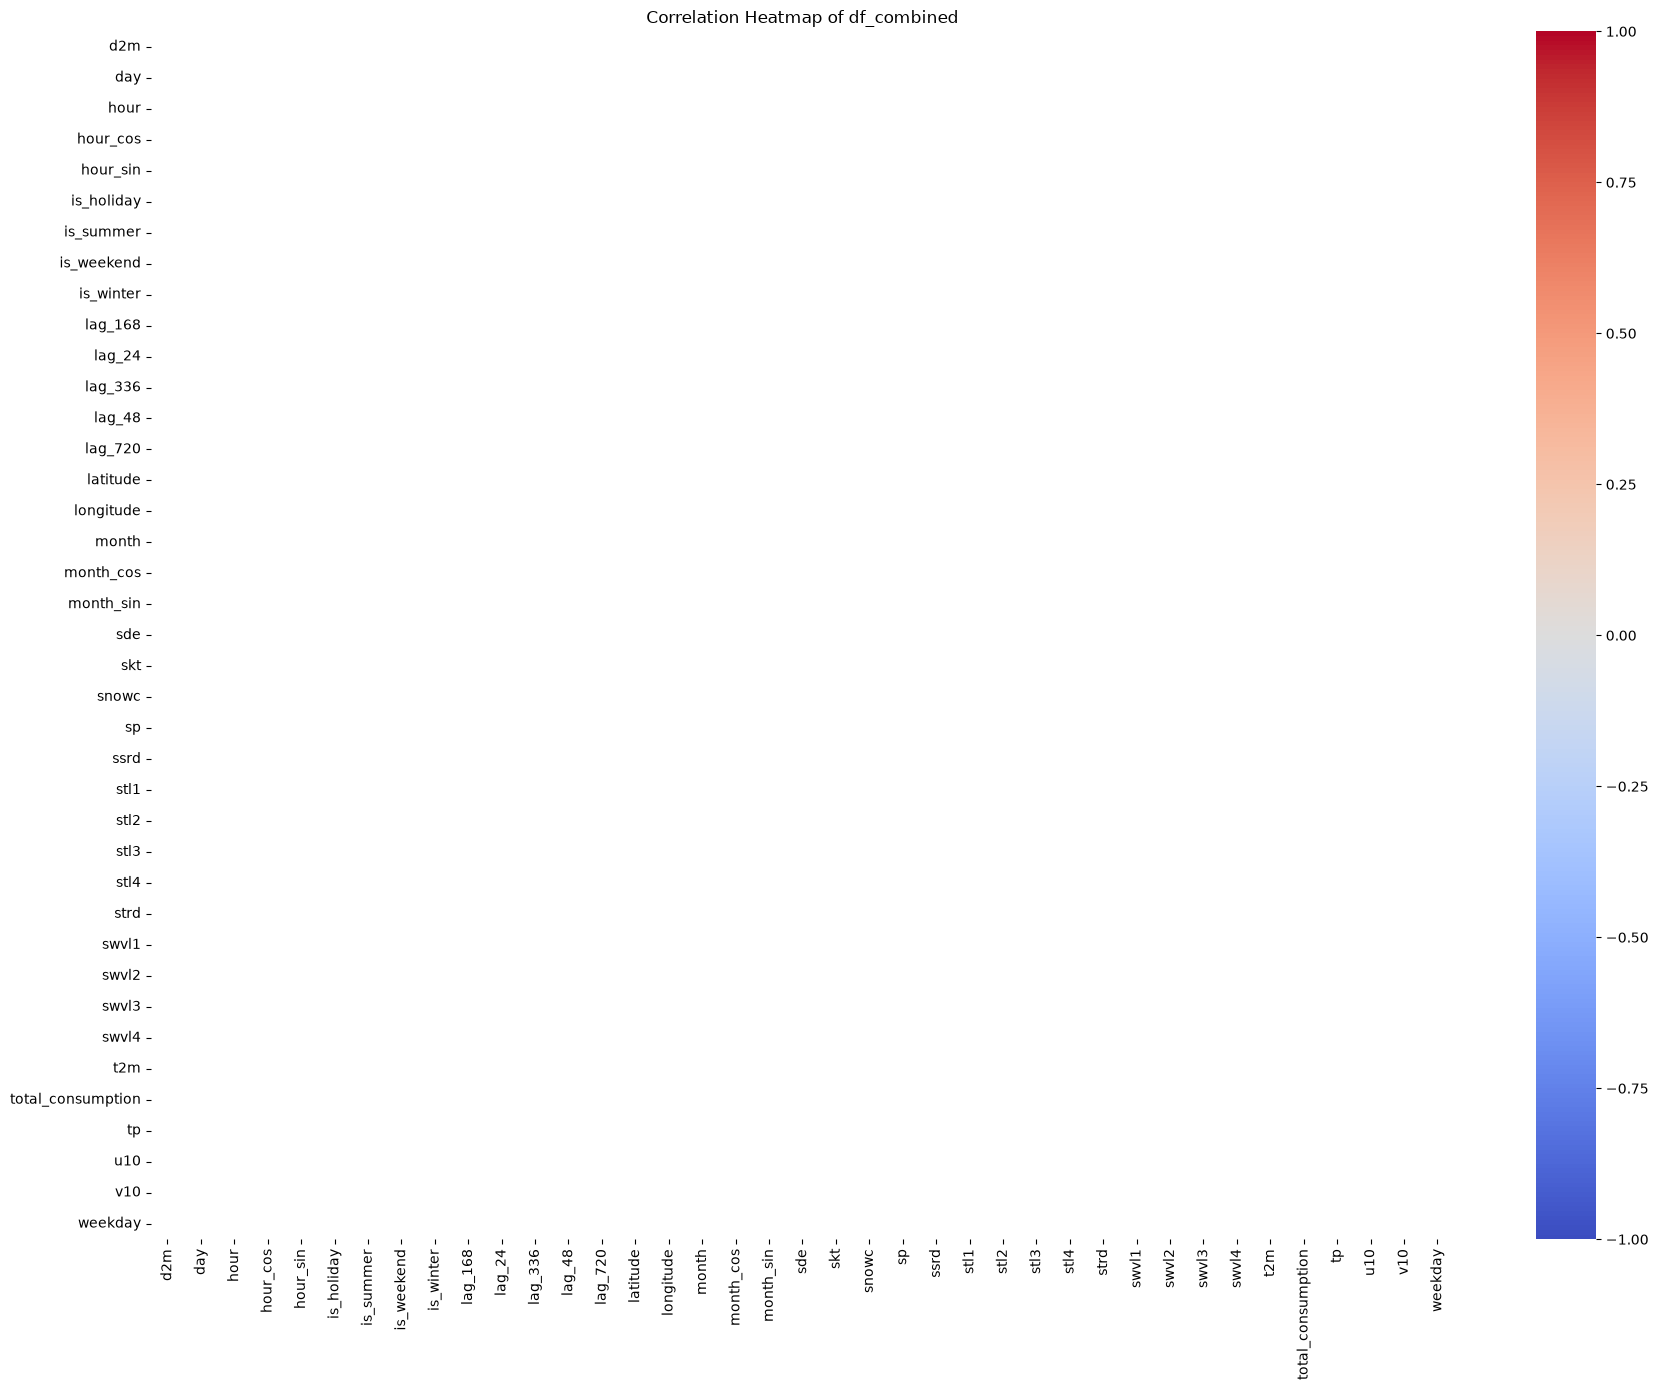

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df_combined.select_dtypes(include="number")

# Calculate correlations
correlation_matrix = numeric_df.corr()

# Display correlations
display(correlation_matrix)

# Plot heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of df_combined")
plt.tight_layout()
plt.show()

In [15]:
## Feature Selection
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select the consumption category you want to predict
target_column = "se3_metered_consumption_excluding_interruptible_load"

# Combine by timestamp
df_features = pd.concat(
    [
        df_demand[[target_column]].rename(columns={target_column: "target"}),
        df_time_series,       # Your engineered lag/calendar features
        df_weather_aligned,
    ],
    axis=1,
).sort_index()

# Coordinates are constant for this single-location dataset
df_features = df_features.drop(
    columns=["latitude", "longitude"],
    errors="ignore",
).select_dtypes(include="number")

assert df_features.columns.is_unique, "Remove duplicate column names first."

# Analyze development data only; preserve the final 20% for testing
split = int(len(df_features) * 0.8)
df_dev = df_features.iloc[:split].copy()

# Constant/all-missing columns have undefined correlations
df_dev = df_dev.loc[:, df_dev.nunique() > 1]

# Pearson: linear relationships
correlation = df_dev.corr(method="pearson")

plt.figure(figsize=(16, 13))

sns.heatmap(
    correlation,
    mask=np.triu(np.ones_like(correlation, dtype=bool), k=1),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=False,
    square=True,
    linewidths=0.2,
    cbar_kws={"label": "Pearson correlation"},
)

plt.title("Time-Series and Weather Feature Correlations — Development Data")
plt.tight_layout()
plt.show()

# Easier-to-read ranking of correlations with demand
target_correlations = correlation["target"].drop("target")
target_correlations = target_correlations.loc[
    target_correlations.abs().sort_values(ascending=False).index
]

display(target_correlations.to_frame("Correlation with demand"))

NameError: name 'df_time_series' is not defined